# AB тестирование часть 5

## Бакетирование

- Бакетирование = группировка данных в «бакеты»
- Вместо работы с сырыми данными → работаем со средними по группам

Пример:
- 1 000 000 точек → 1000 бакетов по 1000 наблюдений

На выходе:
- распределение средних
- доверительные интервалы

**Зачем это нужно?**

- Снижение объёма данных
- Уменьшение дисперсии метрики
- Приближение к нормальному распределению => возможность применять t-тест

- Важно: лучше всего работает для «средних» метрик (метрики, которые считаются как среднее)

**Как работает бакетирование**

1) Перемешиваем данные
2) Делим на непересекающиеся группы (бакеты)
3) Считаем метрику внутри каждого бакета
4) Получаем новое распределение

**Ограничения**
- Слишком мало бакетов → мало наблюдений
- Слишком много → теряется смысл
- Не подходит для всех типов метрик

## Параллельные vs множественные тесты

Множественные:

- один эксперимент
- много гипотез

Параллельные:

- много независимых экспериментов

## Множественное тестирование 

Вопрос множественного тестирования появляется, когда решения о том, насколько успешен эксперимент, основываются на результатах тестирования нескольких гипотез. Простой пример: у нас есть одна контрольная группа и две тестовые группы. Контрольная группа — это действующий алгоритм рекомендаций, который был разработан примерно год назад. В свою очередь, разработаны два или три новых алгоритма. Мы хотим протестировать их одновременно, а не в рамках отдельных экспериментов. Поскольку следует запустить две тестовые группы для проверки новых решений наряду с одной контрольной.

- Проверяем несколько гипотез одновременно
- Растёт вероятность ошибки I рода (ложноположительной)

Формула:

При α = 0.05 и 20 тестах: ошибка ≈ 65%

Следовательно, нужно контролировать α:

- снижать уровень значимости
- уменьшать число ложных отклонений

Однако тогда в результате:

- растёт ошибка II рода
- падает мощность теста

### Подходы к множественному тестированию
FWER (Family-Wise Error Rate) — “не ошибиться ни разу”

Ты контролируешь вероятность сделать хотя бы одну ложную находку

Интуитивно:
- Есть 10 гипотез
- Ты хочешь, чтобы шанс хоть одной ошибки был ≤ 5%

Когда используется:
- медицина (клинические испытания)
- критичные продуктовые изменения
- финансы

Наиболее строгий подход. В нем вероятность допустить хотя бы одну ошибку всегда меньше α

Поправка Бонферрони (Bonferroni)

Идея:

Разделить уровень значимости:

$$\alpha_{new} = \frac{\alpha}{m}$$
	​
где:

m — число гипотез

Например:
- α = 0.05
- 5 гипотез
- новый α = 0.05/5 = 0.01

теперь p-value должен быть < 0.01

Holm-Bonferroni
1. Сортируем p-value от меньшего к большему
2. Сравниваем по очереди с разными порогами:
- α/m
- α/(m-1)

1   0.011   0.05/4=0.0125 (Значимый)

2   0.02    0.05/3=0.0167 (Не значимый)

3   0.045   0.05/2=0.025 (Не значимый)

4   0.06    0.05/1=0.05 (Не значимый)

первый тест — самый строгий
дальше — чуть мягче

Получается, что гипотезы далее наказываются меньше, чем в Bonferoni

# FDR (False Discovery Rate) — “ошибаться можно, но немного”

Ты контролируешь долю ошибок среди всех найденных эффектов

Интуитивно:
- Ты нашёл 10 «значимых» результатов
- FDR = 10% → в среднем 1 из них — ложный

Наименее строгий подход. Получается, что контролируем долю ошибок, которые меньше α

**Benjamini–Hochberg (BH)**

- Сортируешь p-value

- Сравниваешь их с возрастающими порогами:

$$\frac{i}{m}*\alpha$$

- Берёшь все гипотезы до последней прошедшей.

Пример расчета
Предположим, вы провели 4 теста и хотите контролировать FDR на уровне Q=0.05

1   0.011   1/4*0.05=0.0125 (Значимо)

2   0.02    2/4*0.05=0.0250 (Значимо)

3   0.045   3/4*0.05=0.0375 (Не значимо)

4   0.06    4/4*0.05=0.05 (Не значимо)

В данном случае самым большим значимым является, значит, первые две нулевые гипотезы отклоняются.

## Параллельное тестирование

Параллельное тестирование - это когда несколько независимых A/B-экспериментов, идущих одновременно


- решения принимаются отдельно по каждому эксперименту
- это НЕ множественное тестирование (там один эксперимент — много гипотез)

Например одновременно идут:

- маркетинг → тест баннера
- продукт → тест кнопки
- ML → тест рекомендаций

**Проблемы параллельных тестов**
- Пересечение аудиторий
- Влияние экспериментов друг на друга
- Пост-эффекты

Главная проблема

Эксперименты начинают влиять друг на друга

Пример:
- Эксперимент A: «покажи баннер»
- Эксперимент B: «дай 50% скидку»

В итоге эффект от баннера:

- без скидки → слабый
- со скидкой → сильный

Как понять, что реально сработало тяжело

### Типы взаимодействия экспериментов

1) Независимые (safe)

Эксперименты не влияют друг на друга

Пример:
- цвет кнопки
- алгоритм сортировки товаров

Следовательно, их можно запускать вместе без проблем

2) Слабо зависимые

Есть влияние, но небольшое

Пример:
- баннер + layout страницы

Есть пересечение, но лучше контролировать

3) Один эксперимент меняет эффект другого

Пример:
- скидка vs рекомендация
- пуш-уведомление vs email

Смешивать такие эксперементы нельзя

### Подоходы по параллельному тестированию

**Подход 1: Полная изоляция (no overlap)**

Каждый пользователь участвует только в одном эксперименте

Как делается:
- делим аудиторию на сегменты
- каждый сегмент → отдельный эксперимент

Плюсы:
- чистые результаты
- простая интерпретация

Минусы:
- нужна большая аудитория
- медленно

Обязательно использовать когда эксперементы конфликтуют и когда важна точность эксперемента

**Подход 2: Частичное пересечение (controlled overlap)**

Пользователь может быть в нескольких экспериментах, но влияние балансируется с помощью:

- бакетов
- стратификации
- кластеризации

## Подходы к распределению пользователей

### Подход 1: Модульные бакеты

Делим пользователей на фиксированные бакеты
- Пример: ID % N

Плюсы:

- просто

Минусы:

- быстро заканчиваются бакеты
- пользователи «застревают»

### Подход 2: Hash + слои

Используем hash(user_id + salt)
- Каждый salt = новый слой

Плюсы:

- гибкость
- можно запускать больше экспериментов
- лучшее перемешивание

## Общий пайплайн эксперемента

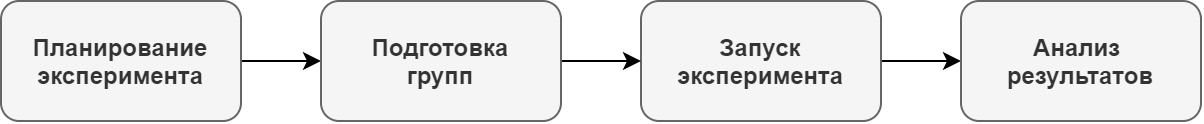

На этапе планирования:
- зафиксировать метрики: определить, какие метрики будут использоваться в качестве целевой, а какие — в качестве защитных метрик, что тоже закрепляет уже пройденные этапы;
- разработка модели поведения клиентов на основе их поведения в прошлом;
- определить уровень расчета метрики и ее струтуру;
- определение гипотез тестирования (нулевая альтернативная), а также их направленности;
- определить дизайн исследования, учитывая количество групп и наличие различий между ними на предпериоде;
- определение ошибки первого рода и мощности теста.

На этапе подготовки групп:
- будут ли проводиться параллельные эксперименты зависимого или независимого типа;
- вычислить численности групп и необходимость стратификации;
- определить rump-up и его необходимость;
- выделить кластеры пользователей и определить их особенности;
- выдвинуть предположения о свойствах групп.